# MODIS/Terra Vegetation Indices 16-Day L3 Global 250m SIN Grid V061

Extracting 2000 data...
Extracting 2026 data...


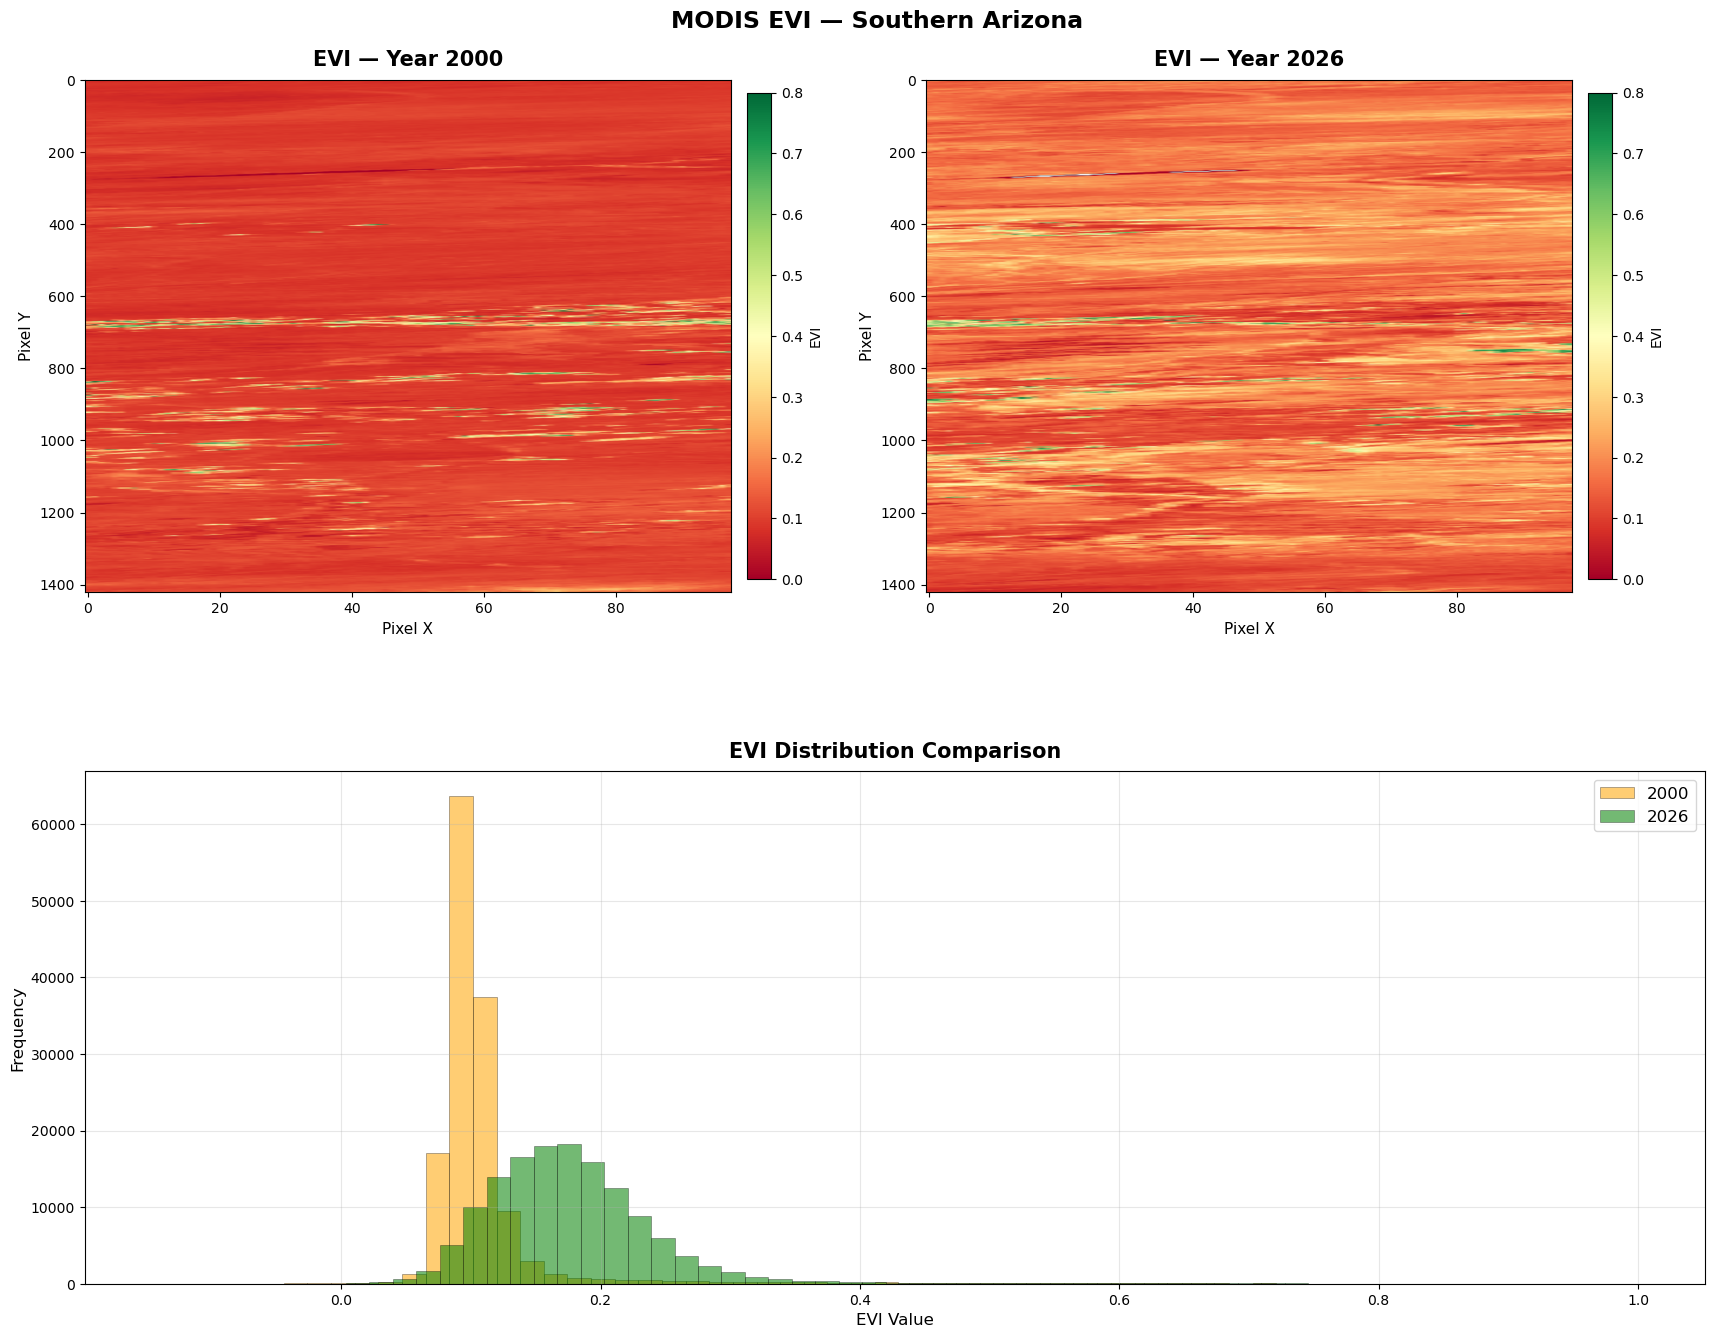


STATISTICS COMPARISON

Metric                       2000         2026       Change
------------------------------------------------------------
Mean EVI                   0.1085       0.1777       0.0692
Median EVI                 0.0978       0.1699       0.0707
Std Dev                    0.0577       0.0708       0.0838
Min EVI                   -0.0990      -0.1411
Max EVI                    0.9946       0.9446

Pixels with >0.1 increase           40315 ( 29.0%)
Pixels with >0.1 decrease            2848 (  2.0%)


In [1]:
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

gdal.UseExceptions()

# Your Arizona bounding box
min_lon, min_lat, max_lon, max_lat = -114.397705, 31.848272, -110.332764, 34.809894
R = 6371007.181  # Earth radius

def latlon_to_sinusoidal(lon, lat, R):
    lat_rad = lat * np.pi / 180
    lon_rad = lon * np.pi / 180
    x = R * lon_rad * np.cos(lat_rad)
    y = R * lat_rad
    return x, y

def sinusoidal_to_pixel(x, y, geotransform):
    origin_x = geotransform[0]
    origin_y = geotransform[3]
    pixel_width = geotransform[1]
    pixel_height = geotransform[5]
    col = int((x - origin_x) / pixel_width)
    row = int((y - origin_y) / pixel_height)
    return row, col

def extract_evi_region(filename, min_lon, min_lat, max_lon, max_lat):
    dataset = gdal.Open(filename)
    subdatasets = dataset.GetSubDatasets()
    evi_dataset = gdal.Open(subdatasets[1][0])
    geotransform = evi_dataset.GetGeoTransform()

    ul_x, ul_y = latlon_to_sinusoidal(min_lon, max_lat, R)
    lr_x, lr_y = latlon_to_sinusoidal(max_lon, min_lat, R)

    row_min, col_min = sinusoidal_to_pixel(ul_x, ul_y, geotransform)
    row_max, col_max = sinusoidal_to_pixel(lr_x, lr_y, geotransform)

    evi_array = evi_dataset.ReadAsArray()

    rows, cols = evi_array.shape
    row_min = max(0, row_min)
    row_max = min(rows, row_max)
    col_min = max(0, col_min)
    col_max = min(cols, col_max)

    evi_region = evi_array[row_min:row_max, col_min:col_max]
    evi_scaled = evi_region.astype(float) / 10000.0
    evi_scaled[evi_region < -2000] = np.nan

    return evi_scaled

# Extract EVI from both files
print("Extracting 2000 data...")
evi_2000 = extract_evi_region('MOD13Q1.A2000049.h08v05.061.2020041152304.hdf',
                               min_lon, min_lat, max_lon, max_lat)

print("Extracting 2026 data...")
evi_2026 = extract_evi_region('MOD13Q1.A2026017.h08v05.061.2026034004018.hdf',
                               min_lon, min_lat, max_lon, max_lat)

evi_diff = evi_2026 - evi_2000

# --- 3-panel layout: two maps on top, histogram on bottom ---
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.35,
    wspace=0.08,
    left=0.06, right=0.96,
    top=0.93, bottom=0.07
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])   # histogram spans full bottom row

# 2000 EVI
im1 = ax1.imshow(evi_2000, cmap='RdYlGn', vmin=0, vmax=0.8, aspect='auto')
ax1.set_title('EVI — Year 2000', fontsize=15, fontweight='bold', pad=10)
ax1.set_xlabel('Pixel X', fontsize=11)
ax1.set_ylabel('Pixel Y', fontsize=11)
plt.colorbar(im1, ax=ax1, label='EVI', shrink=0.95, pad=0.02)

# 2026 EVI
im2 = ax2.imshow(evi_2026, cmap='RdYlGn', vmin=0, vmax=0.8, aspect='auto')
ax2.set_title('EVI — Year 2026', fontsize=15, fontweight='bold', pad=10)
ax2.set_xlabel('Pixel X', fontsize=11)
ax2.set_ylabel('Pixel Y', fontsize=11)
plt.colorbar(im2, ax=ax2, label='EVI', shrink=0.95, pad=0.02)

# Histogram
ax3.hist(evi_2000[~np.isnan(evi_2000)].flatten(), bins=60, alpha=0.55,
         label='2000', color='orange', edgecolor='black', linewidth=0.4)
ax3.hist(evi_2026[~np.isnan(evi_2026)].flatten(), bins=60, alpha=0.55,
         label='2026', color='green', edgecolor='black', linewidth=0.4)
ax3.set_xlabel('EVI Value', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('EVI Distribution Comparison', fontsize=15, fontweight='bold', pad=10)
ax3.legend(fontsize=12)
ax3.grid(alpha=0.3)

fig.suptitle('MODIS EVI — Southern Arizona', fontsize=17, fontweight='bold', y=0.98)

plt.savefig('evi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
print("\n" + "="*50)
print("STATISTICS COMPARISON")
print("="*50)
print(f"\n{'Metric':<20} {'2000':>12} {'2026':>12} {'Change':>12}")
print("-"*60)
print(f"{'Mean EVI':<20} {np.nanmean(evi_2000):>12.4f} {np.nanmean(evi_2026):>12.4f} {np.nanmean(evi_diff):>12.4f}")
print(f"{'Median EVI':<20} {np.nanmedian(evi_2000):>12.4f} {np.nanmedian(evi_2026):>12.4f} {np.nanmedian(evi_diff):>12.4f}")
print(f"{'Std Dev':<20} {np.nanstd(evi_2000):>12.4f} {np.nanstd(evi_2026):>12.4f} {np.nanstd(evi_diff):>12.4f}")
print(f"{'Min EVI':<20} {np.nanmin(evi_2000):>12.4f} {np.nanmin(evi_2026):>12.4f}")
print(f"{'Max EVI':<20} {np.nanmax(evi_2000):>12.4f} {np.nanmax(evi_2026):>12.4f}")

significant_increase = np.sum(evi_diff > 0.1)
significant_decrease = np.sum(evi_diff < -0.1)
total_valid = np.sum(~np.isnan(evi_diff))

print(f"\n{'Pixels with >0.1 increase':<30} {significant_increase:>10} ({100*significant_increase/total_valid:>5.1f}%)")
print(f"{'Pixels with >0.1 decrease':<30} {significant_decrease:>10} ({100*significant_decrease/total_valid:>5.1f}%)")

# MERRA-2 Climate Reanalysis File

In [2]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# Open the NetCDF file
dataset = nc.Dataset('MERRA2_200.tavg1_2d_slv_Nx.20000101.nc4', 'r')

# Explore what's in the file
print("Variables in file:")
print("="*60)
for var_name in dataset.variables.keys():
    var = dataset.variables[var_name]
    print(f"{var_name:20s} - {var.long_name if hasattr(var, 'long_name') else 'No description'}")

print("\n" + "="*60)
print("Dimensions:")
for dim_name, dim in dataset.dimensions.items():
    print(f"{dim_name}: {len(dim)}")

# Close for now
dataset.close()

Variables in file:
lon                  - longitude
lat                  - latitude
time                 - time
CLDPRS               - cloud_top_pressure
CLDTMP               - cloud_top_temperature
DISPH                - zero_plane_displacement_height
H1000                - height_at_1000_mb
H250                 - height_at_250_hPa
H500                 - height_at_500_hPa
H850                 - height_at_850_hPa
OMEGA500             - omega_at_500_hPa
PBLTOP               - pbltop_pressure
PS                   - surface_pressure
Q250                 - specific_humidity_at_250_hPa
Q500                 - specific_humidity_at_500_hPa
Q850                 - specific_humidity_at_850_hPa
QV10M                - 10-meter_specific_humidity
QV2M                 - 2-meter_specific_humidity
SLP                  - sea_level_pressure
T10M                 - 10-meter_air_temperature
T250                 - air_temperature_at_250_hPa
T2M                  - 2-meter_air_temperature
T2MDEW               -

Processing 2000 data...
Processing 2026 data...


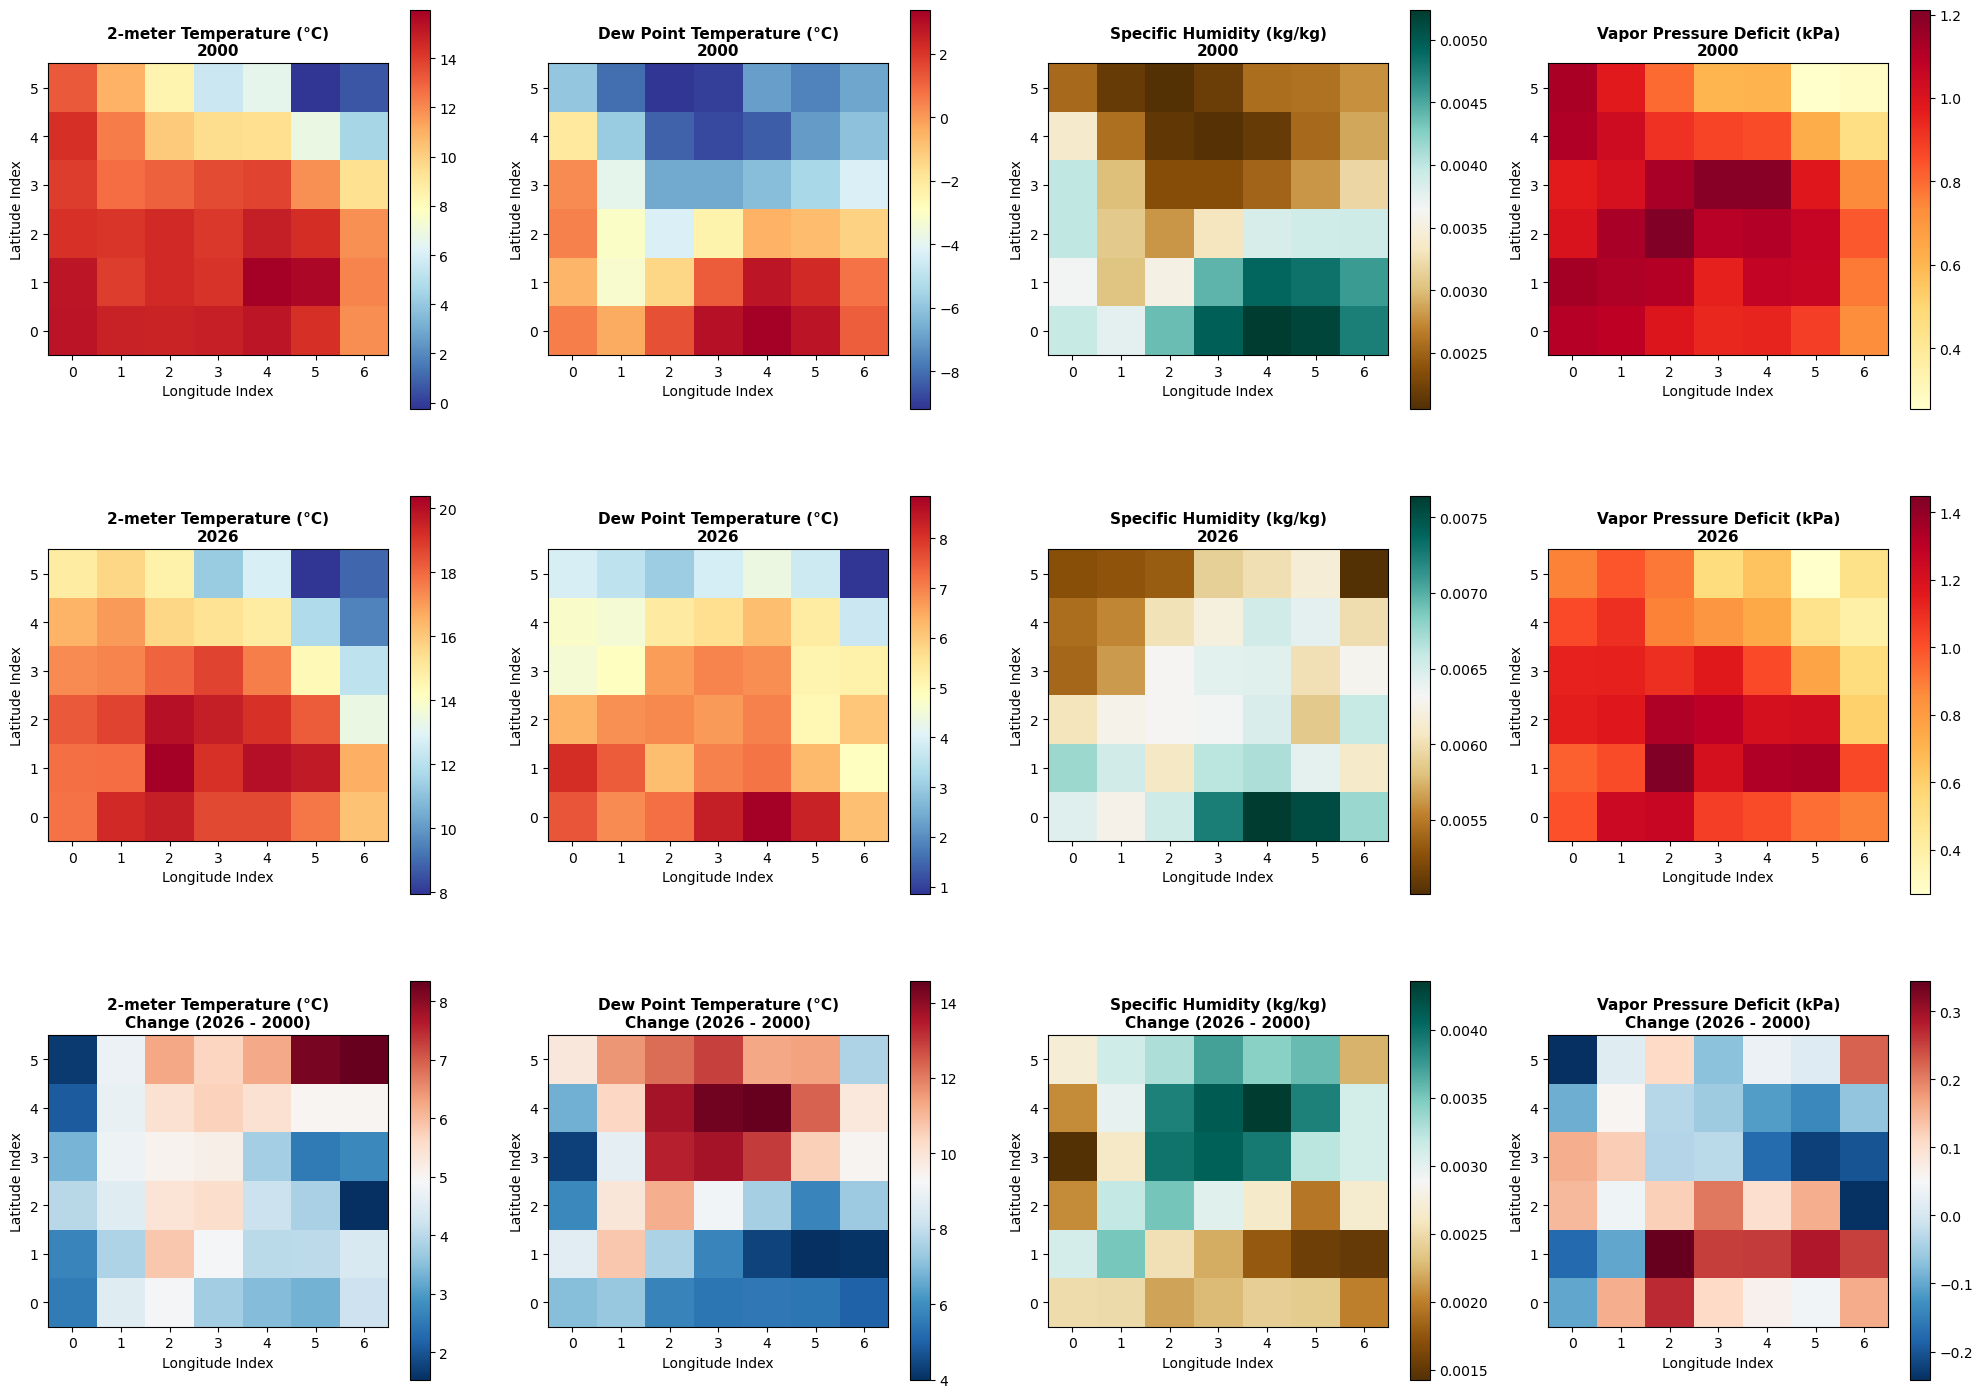


ATMOSPHERIC CONDITIONS COMPARISON (January 1st)

2-meter Temperature (°C):
Metric                               2000            2026          Change
--------------------------------------------------------------------------------
Mean                              11.9406         16.3970          4.4565
Median                            13.6942         17.5002          4.5169
Std Dev                            3.8619          3.1383
Min                               -0.2433          7.9338
Max                               15.9637         20.3947

Dew Point Temperature (°C):
Metric                               2000            2026          Change
--------------------------------------------------------------------------------
Mean                              -3.1209          5.8129          8.9337
Median                            -3.1559          6.1608          8.9319
Std Dev                            3.8848          1.6223
Min                               -9.1852          0.8444

/home/zacharyhansen/.conda/envs/edgeofdesert/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [3]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# Your Arizona bounding box
min_lon, min_lat, max_lon, max_lat = -114.397705, 31.848272, -110.332764, 34.809894

def extract_region(dataset, var_name, lat_idx, lon_idx, time_idx=0):
    """Extract a variable for the Arizona region"""
    var = dataset.variables[var_name][time_idx, lat_idx[0]:lat_idx[-1]+1, lon_idx[0]:lon_idx[-1]+1]
    return var

def calculate_vpd(t2m, t2mdew):
    """Calculate Vapor Pressure Deficit from temperature and dew point (in Kelvin)"""
    # Convert to Celsius
    t_celsius = t2m - 273.15
    td_celsius = t2mdew - 273.15
    
    # Saturation vapor pressure at air temp (kPa)
    es = 0.611 * np.exp((17.27 * t_celsius) / (t_celsius + 237.3))
    # Actual vapor pressure at dew point (kPa)
    ea = 0.611 * np.exp((17.27 * td_celsius) / (td_celsius + 237.3))
    # VPD (kPa)
    vpd = es - ea
    
    return vpd

def process_merra_file(filename, lat_range, lon_range):
    """Process a MERRA-2 file and extract variables for Arizona"""
    dataset = nc.Dataset(filename, 'r')
    
    # Read coordinates
    lats = dataset.variables['lat'][:]
    lons = dataset.variables['lon'][:]
    
    # Find indices for Arizona bounding box
    lat_idx = np.where((lats >= lat_range[0]) & (lats <= lat_range[1]))[0]
    lon_idx = np.where((lons >= lon_range[0]) & (lons <= lon_range[1]))[0]
    
    # Extract variables
    t2m = extract_region(dataset, 'T2M', lat_idx, lon_idx)
    t2mdew = extract_region(dataset, 'T2MDEW', lat_idx, lon_idx)
    qv2m = extract_region(dataset, 'QV2M', lat_idx, lon_idx)
    
    # Calculate VPD
    vpd = calculate_vpd(t2m, t2mdew)
    
    # Convert temperatures to Celsius
    t2m_c = t2m - 273.15
    t2mdew_c = t2mdew - 273.15
    
    dataset.close()
    
    return {
        'T2M': t2m_c,
        'T2MDEW': t2mdew_c,
        'QV2M': qv2m,
        'VPD': vpd,
        'lat_idx': lat_idx,
        'lon_idx': lon_idx
    }

# Process both files
print("Processing 2000 data...")
data_2000 = process_merra_file('MERRA2_200.tavg1_2d_slv_Nx.20000101.nc4', 
                                (min_lat, max_lat), (min_lon, max_lon))

print("Processing 2026 data...")
data_2026 = process_merra_file('MERRA2_400.tavg1_2d_slv_Nx.20260101.nc4', 
                                (min_lat, max_lat), (min_lon, max_lon))

# Calculate differences
diff = {
    'T2M': data_2026['T2M'] - data_2000['T2M'],
    'T2MDEW': data_2026['T2MDEW'] - data_2000['T2MDEW'],
    'QV2M': data_2026['QV2M'] - data_2000['QV2M'],
    'VPD': data_2026['VPD'] - data_2000['VPD']
}

# Create comprehensive comparison plot
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

variables = ['T2M', 'T2MDEW', 'QV2M', 'VPD']
titles = ['2-meter Temperature (°C)', 'Dew Point Temperature (°C)', 
          'Specific Humidity (kg/kg)', 'Vapor Pressure Deficit (kPa)']
cmaps = ['RdYlBu_r', 'RdYlBu_r', 'BrBG', 'YlOrRd']
diff_cmaps = ['RdBu_r', 'RdBu_r', 'BrBG', 'RdBu_r']

for i, (var, title, cmap, diff_cmap) in enumerate(zip(variables, titles, cmaps, diff_cmaps)):
    # 2000
    im1 = axes[0, i].imshow(data_2000[var], cmap=cmap, origin='lower')
    axes[0, i].set_title(f'{title}\n2000', fontsize=11, fontweight='bold')
    plt.colorbar(im1, ax=axes[0, i], shrink=0.8)
    
    # 2026
    im2 = axes[1, i].imshow(data_2026[var], cmap=cmap, origin='lower')
    axes[1, i].set_title(f'{title}\n2026', fontsize=11, fontweight='bold')
    plt.colorbar(im2, ax=axes[1, i], shrink=0.8)
    
    # Difference
    im3 = axes[2, i].imshow(diff[var], cmap=diff_cmap, origin='lower')
    axes[2, i].set_title(f'{title}\nChange (2026 - 2000)', fontsize=11, fontweight='bold')
    plt.colorbar(im3, ax=axes[2, i], shrink=0.8)

for ax in axes.flat:
    ax.set_xlabel('Longitude Index')
    ax.set_ylabel('Latitude Index')

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("ATMOSPHERIC CONDITIONS COMPARISON (January 1st)")
print("="*80)

for var, title in zip(variables, titles):
    print(f"\n{title}:")
    print(f"{'Metric':<25} {'2000':>15} {'2026':>15} {'Change':>15}")
    print("-"*80)
    print(f"{'Mean':<25} {np.mean(data_2000[var]):>15.4f} {np.mean(data_2026[var]):>15.4f} {np.mean(diff[var]):>15.4f}")
    print(f"{'Median':<25} {np.median(data_2000[var]):>15.4f} {np.median(data_2026[var]):>15.4f} {np.median(diff[var]):>15.4f}")
    print(f"{'Std Dev':<25} {np.std(data_2000[var]):>15.4f} {np.std(data_2026[var]):>15.4f}")
    print(f"{'Min':<25} {np.min(data_2000[var]):>15.4f} {np.min(data_2026[var]):>15.4f}")
    print(f"{'Max':<25} {np.max(data_2000[var]):>15.4f} {np.max(data_2026[var]):>15.4f}")

# Drought stress interpretation
print("\n" + "="*80)
print("DROUGHT STRESS INDICATORS:")
print("="*80)

mean_vpd_2000 = np.mean(data_2000['VPD'])
mean_vpd_2026 = np.mean(data_2026['VPD'])
vpd_change = mean_vpd_2026 - mean_vpd_2000

print(f"\nMean VPD 2000: {mean_vpd_2000:.3f} kPa")
print(f"Mean VPD 2026: {mean_vpd_2026:.3f} kPa")
print(f"Change: {vpd_change:.3f} kPa ({100*vpd_change/mean_vpd_2000:.1f}%)")

if vpd_change > 0.2:
    print("\n⚠️  SEVERE INCREASE in atmospheric drought stress")
elif vpd_change > 0.1:
    print("\n⚠️  MODERATE INCREASE in atmospheric drought stress")
elif vpd_change > 0:
    print("\n⚠️  SLIGHT INCREASE in atmospheric drought stress")
else:
    print("\n✓ Atmospheric drought stress decreased or remained stable")

mean_temp_change = np.mean(diff['T2M'])
print(f"\nMean Temperature Change: {mean_temp_change:.2f}°C")

if mean_temp_change > 2:
    print("⚠️  SIGNIFICANT warming detected")
elif mean_temp_change > 1:
    print("⚠️  MODERATE warming detected")
elif mean_temp_change > 0:
    print("⚠️  SLIGHT warming detected")